In [2]:
import numpy as np
import pandas as pd
import EFC_learningfMRI.globals as gl
import matplotlib.pyplot as plt
import nitools as nt
import nitools.spm as spm
from nitools.spm import spm_hrf
import nibabel as nb
from EFC_learningfMRI.util import calc_R2
import os
from EFC_learningfMRI.hrf import Optimise_HRF

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


P=[7, 16, 0.8, 1, 6, 0, 32]
R2=0.04711367191490379


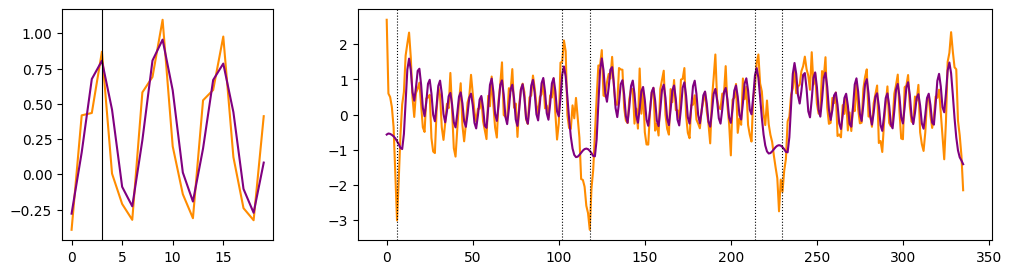

In [7]:
sn = 118
H = 'L'
roi = 'M1'
glm = 3

HRF = Optimise_HRF(sn=sn, glm=glm, H=H,)

P = [7, 16, .8, 1, 6, 0, 32]

y_hat, y_adj, y_raw, y_cut_hat, y_cut_adj, y_cut_raw = HRF.manual(P, pre=3, post=16)

y_cut_raw -= y_cut_raw.mean(axis=1, keepdims=True) 
y_raw -= y_raw.mean(axis=0, keepdims=True) 

R2 = calc_R2(y_adj, y_hat)

print(f'P={P}')
print(f'R2={R2}')

y_raw_bl = np.array(np.split(y_raw, y_raw.shape[0] // gl.nTR, axis=0))
y_adj_bl = np.array(np.split(y_adj, y_adj.shape[0] // gl.nTR, axis=0))
y_hat_bl = np.array(np.split(y_hat, y_hat.shape[0] // gl.nTR, axis=0))

fig, axs = plt.subplots(1, 2, gridspec_kw={'width_ratios': (1, 3)}, figsize=(12, 3), )

axs[0].plot(y_cut_adj.mean(axis=(0, -1)), color='darkorange')
axs[0].plot(y_cut_hat.mean(axis=(0, -1)), color='purple')
axs[0].axvline(3, ls='-', lw=.8, color='k')
axs[1].plot(y_adj_bl.mean(axis=(0, -1)) , color='darkorange')
axs[1].plot(y_hat_bl.mean(axis=(0, -1)), color='purple')
axs[1].axvline(6, ls=':', lw=.8, color='k')
axs[1].axvline(102, ls=':', lw=.8, color='k')
axs[1].axvline(118, ls=':', lw=.8, color='k')
axs[1].axvline(214, ls=':', lw=.8, color='k')
axs[1].axvline(230, ls=':', lw=.8, color='k')

plt.show()

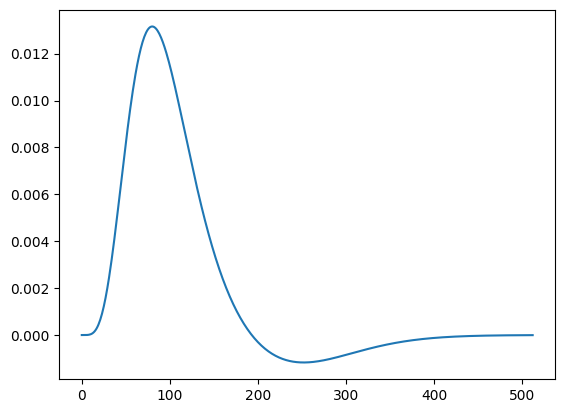

In [3]:
hrf, _ = spm.spm_hrf(1, P=P)
plt.plot(hrf)

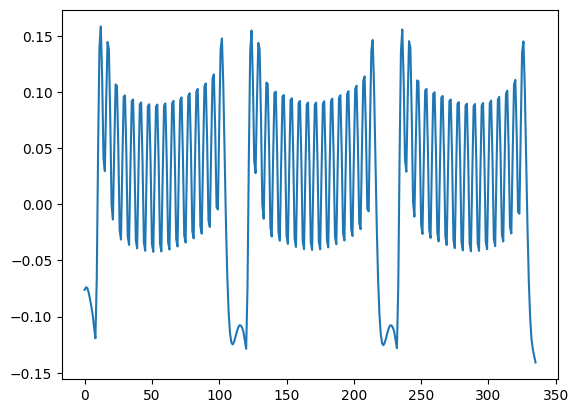

In [4]:
X = HRF.SPM.design_matrix[:, :-30]
X_seg = np.array(np.split(X, X.shape[0] // gl.nTR, axis=0))

X_seg.shape
plt.plot(X_seg.sum(axis=-1).mean(axis=0))
plt.show()
#X_seg.sum(axis=-1).shape

In [5]:
y_raw.shape

(10080, 369)

In [6]:
X.shape

(10080, 240)

In [7]:
X = np.load(os.path.join(gl.baseDir, 'glm3', 'subj116', 'BOLD.adj.L.M1.npy'))

In [8]:
X.shape

(9072, 435)

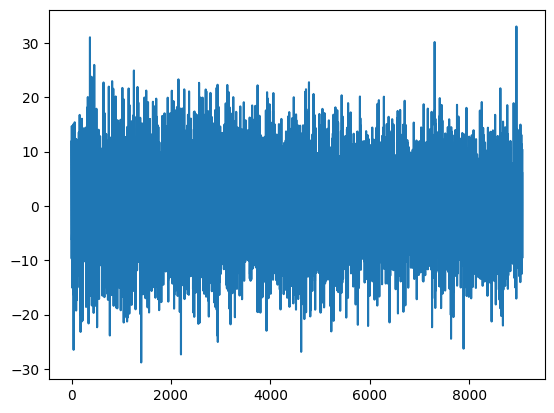

In [9]:
plt.plot(X[:, 0])